# Import Libraries #

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [6]:
df = pd.read_csv("flipkart_sales.csv")

# Understand Dataset

In [8]:
df

,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1
...,...,...,...,...,...,...,...,...,...
995,ORD00996,Smartphone,Electronics,28995.81,3,86987.43,2025-01-13,COD,5.0
996,ORD00997,Perfume,Beauty,32799.51,2,65599.02,2024-12-18,Wallet,2.4
997,ORD00998,Face Cream,Beauty,40840.80,1,40840.80,2024-07-26,UPI,3.1
998,ORD00999,Cookware Set,Home & Kitchen,34741.79,4,138967.16,2024-10-02,Net Banking,3.2


In [9]:
df.head()

,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order ID           1000 non-null   object 
 1   Product Name       1000 non-null   object 
 2   Category           1000 non-null   object 
 3   Price (INR)        1000 non-null   float64
 4   Quantity Sold      1000 non-null   int64  
 5   Total Sales (INR)  1000 non-null   float64
 6   Order Date         1000 non-null   object 
 7   Payment Method     1000 non-null   object 
 8   Customer Rating    1000 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB


In [11]:
df.describe()

,Price (INR),Quantity Sold,Total Sales (INR),Customer Rating
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,24520.258260,3.097000,75213.112740,3.011100
std,14187.611227,1.410525,59457.598352,1.145408
min,139.850000,1.000000,419.550000,1.000000
25%,12378.905000,2.000000,28581.765000,2.000000
50%,24650.015000,3.000000,57358.300000,3.100000
75%,35981.925000,4.000000,110618.595000,4.000000
max,49911.750000,5.000000,243903.900000,5.000000


# Data Cleaning

#Check Missing Values

In [14]:
df.isnull().sum()

Order ID             0
Product Name         0
Category             0
Price (INR)          0
Quantity Sold        0
Total Sales (INR)    0
Order Date           0
Payment Method       0
Customer Rating      0
dtype: int64

In [15]:
df.dropna(inplace = True)

#Remove Duplicates

In [17]:
df.drop_duplicates(inplace=True)

#Convert Date Column

In [19]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Feature Engineering

#Create Month Column

In [22]:
df['Month'] = df['Order Date'].dt.month_name()

#Create Year Column

In [24]:
df['Year'] = df['Order Date'].dt.year

#Create Day Column

In [26]:
df['Day'] = df['Order Date'].dt.day_name()

# Exploratory Data Analysis (EDA)

#Which category has highest sales?

In [29]:
category_sales = df.groupby('Category')['Total Sales (INR)'].sum()

print(category_sales)

Category
Beauty            14680584.05
Books             14785759.65
Clothing          15114386.86
Electronics       17307173.07
Home & Kitchen    13325209.11
Name: Total Sales (INR), dtype: float64


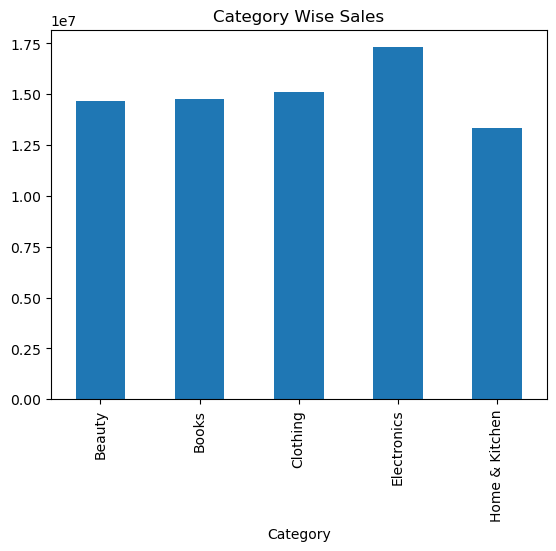

In [30]:
category_sales.plot(kind='bar')
plt.title("Category Wise Sales")
plt.show()

#Which products sell most?

In [32]:
top_products = df.groupby('Product Name')['Quantity Sold'].sum().sort_values(ascending=False)

print(top_products.head(10))

Product Name
Educational Book    188
Laptop              156
Table Lamp          141
Fiction Novel       138
Smartwatch          137
Headphones          135
Lipstick            134
Jeans               132
T-Shirt             131
Sneakers            125
Name: Quantity Sold, dtype: int64


Monthly Sales Trend

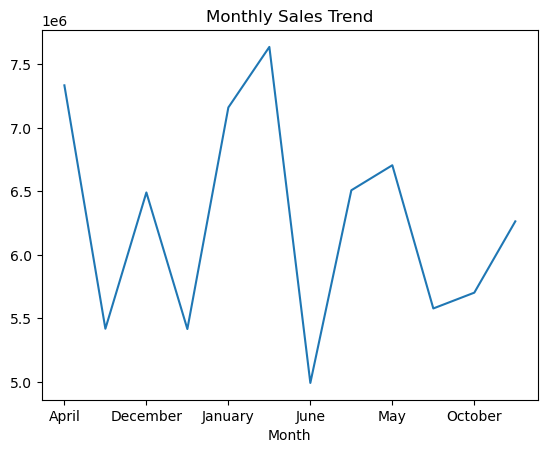

In [34]:
monthly_sales = df.groupby('Month')['Total Sales (INR)'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

#Most Used Payment Method

In [36]:
print(df['Payment Method'].value_counts())

Payment Method
UPI            176
Wallet         172
Debit Card     171
COD            169
Net Banking    166
Credit Card    146
Name: count, dtype: int64


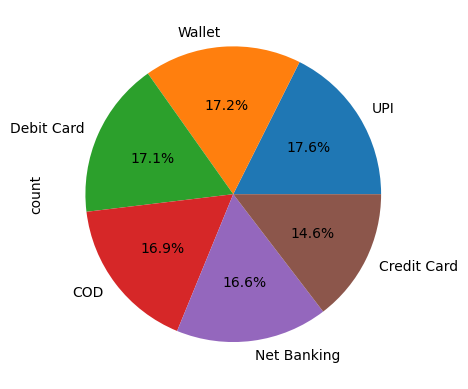

In [37]:
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

#Average Customer Rating by Category

In [39]:
ratings = df.groupby('Category')['Customer Rating'].mean()

print(ratings)

Category
Beauty            2.872396
Books             3.079904
Clothing          2.971429
Electronics       2.988479
Home & Kitchen    3.138860
Name: Customer Rating, dtype: float64


#Rating vs Sales

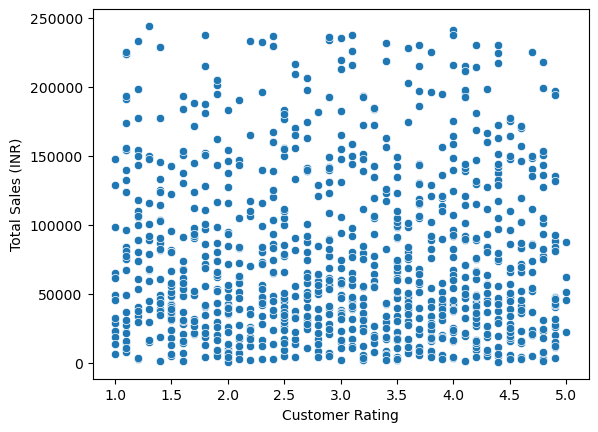

In [41]:
sns.scatterplot(x='Customer Rating', y='Total Sales (INR)', data=df)

plt.show()

# Save Cleaned Dataset

In [87]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [85]:
df.to_csv("cleaned_Flipkart_Sales.csv", index=False, encoding='utf-8-sig')